In [1]:
import pandas as pd
import glob
import os

In [2]:
# ds_bill = pd.read_csv('/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/TrainData/ds_numService_with_billing.csv',sep=',')
ds_bill = pd.read_csv('bill_22_24_filtered.csv',sep='^') # GET 2024 BILL

In [3]:
ds_bill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4950843 entries, 0 to 4950842
Data columns (total 8 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   客編      int64 
 1   相關編號    int64 
 2   帳單起日    object
 3   帳單迄日    object
 4   金額      int64 
 5   銷帳日期    object
 6   繳別      int64 
 7   繳費方式    object
dtypes: int64(4), object(4)
memory usage: 302.2+ MB


In [4]:
ds_bill_filtered = ds_bill[ds_bill['金額'] != 0].copy()  # 建立副本
ds_bill_filtered.loc[:, '帳單起日'] = pd.to_datetime(ds_bill_filtered['帳單起日'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# 篩選帳單起日在 2024 年至 2024 年之間的資料
ds_bill_filtered = ds_bill_filtered[
    (ds_bill_filtered['帳單起日'] >= pd.Timestamp('2024-01-01')) &
    (ds_bill_filtered['帳單起日'] <= pd.Timestamp('2024-12-31'))
]

In [5]:
ds_bill_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1711424 entries, 141181 to 4950401
Data columns (total 8 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   客編      int64 
 1   相關編號    int64 
 2   帳單起日    object
 3   帳單迄日    object
 4   金額      int64 
 5   銷帳日期    object
 6   繳別      int64 
 7   繳費方式    object
dtypes: int64(4), object(4)
memory usage: 117.5+ MB


In [6]:
ds_bill_filtered.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式
141181,973001,1453080,2024-11-16 00:00:00,2025/08/18 00:00:00,14620,25-3月 -22,6,大樓集收
257401,981424,1507302,2024-04-18 00:00:00,2025/04/17 00:00:00,5700,28-3月 -22,12,CVS臨櫃代收(7-11)
257447,973001,1453079,2024-11-16 00:00:00,2025/08/18 00:00:00,610,30-3月 -22,9,大樓集收
257448,973002,1453078,2024-11-16 00:00:00,2025/08/18 00:00:00,609,30-3月 -22,9,大樓集收
257449,973003,1453077,2024-11-16 00:00:00,2025/08/18 00:00:00,609,30-3月 -22,9,大樓集收


In [20]:
ds_bill_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1711424 entries, 141181 to 4950401
Data columns (total 8 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   客編      int64 
 1   相關編號    int64 
 2   帳單起日    object
 3   帳單迄日    object
 4   金額      int64 
 5   銷帳日期    object
 6   繳別      int64 
 7   繳費方式    object
dtypes: int64(4), object(4)
memory usage: 117.5+ MB


In [7]:
ds_bill_filtered.value_counts('繳別')

繳別
1     943655
6     323240
3     214841
12    126776
2      71218
4       9401
24      5296
15      4706
36      2595
18      1958
7       1106
14       877
60       617
48       599
11       541
5        495
42       427
10       390
8        321
16       320
9        296
30       290
13       215
38       183
32       112
21       104
28        98
20        96
39        94
37        89
27        76
23        61
26        46
17        44
41        40
40        38
22        33
19        32
50        23
29        23
51        21
25        16
33        15
Name: count, dtype: int64

In [8]:
bill = ds_bill_filtered.copy()  # 建立副本

# 👉 將 '銷帳日期' 中中文月份轉為英文縮寫（供 datetime 解析）
month_map = {
    '1月': 'Jan', '2月': 'Feb', '3月': 'Mar', '4月': 'Apr',
    '5月': 'May', '6月': 'Jun', '7月': 'Jul', '8月': 'Aug',
    '9月': 'Sep', '10月': 'Oct', '11月': 'Nov', '12月': 'Dec'
}

# 替換中文月份
for zh, en in month_map.items():
    bill['銷帳日期'] = bill['銷帳日期'].str.replace(zh, en, regex=False)

# 轉換為 datetime 格式
bill['銷帳日期'] = pd.to_datetime(bill['銷帳日期'], format='%d-%b -%y', errors='coerce')

# 解析 '帳單迄日'
bill['帳單起日'] = pd.to_datetime(bill['帳單起日'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# 計算延遲日數
bill['繳款延遲日數'] = (bill['銷帳日期'] - bill['帳單起日']).dt.days

# 移除無效記錄以計算平均
valid_bills = bill.dropna(subset=['繳款延遲日數'])
avg_global = round(valid_bills['繳款延遲日數'].mean(), 2)

# 平均延遲日數
delay_avg = bill.groupby('客編')['繳款延遲日數'].mean().reset_index()
delay_avg.columns = ['客編', '平均繳款延遲日數']

# 將全體平均補進 NaN 的客戶
all_customers = bill[['客編']].drop_duplicates()
delay_filled = pd.merge(all_customers, delay_avg, on='客編', how='left')
delay_filled['平均繳款延遲日數'] = delay_filled['平均繳款延遲日數'].fillna(avg_global)

# 最常見繳費方式
payment_mode = bill.groupby('客編')['繳費方式'] \
                   .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else '未知') \
                   .reset_index()
payment_mode.columns = ['客編', '最常見繳費方式']

# 合併帳單特徵
# bill_features = pd.merge(delay_avg, payment_mode, on='客編', how='outer')
bill_features = pd.merge(delay_filled, payment_mode, on='客編', how='left')

# 計算每個客編最常見的繳別
most_common_paytype = bill.groupby('客編')['繳別'].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
).reset_index()
# most_common_paytype.columns = ['客編', '最常見繳別']

# 合併到 bill_features
bill_features_enhanced = pd.merge(bill_features, most_common_paytype, on='客編', how='left')


In [9]:
bill_features_enhanced.value_counts('最常見繳費方式')

最常見繳費方式
CVS臨櫃代收(7-11)     128110
簡訊帳單臨櫃代收(7-11)     90574
大樓集收               42058
廠商代收               29196
當月繳帳單              28590
金融機構轉帳             15295
個月繳帳單               4731
信用卡扣款               3276
劃撥繳款                2769
稽核收款                 509
待處理戶                 505
其他方式繳款               346
APP自動扣款              343
需先請款                 216
APP臨櫃代收(7-11)        185
金融機構繳款               175
票據繳款                 149
指定到府收費                76
人工收費單                 46
客戶自行繳款                34
專案收款                  20
大樓指定收費                20
Name: count, dtype: int64

In [10]:
bill_features_enhanced.head()

,客編,平均繳款延遲日數,最常見繳費方式,繳別
0,973001,-964.5,大樓集收,6
1,981424,-752.0,CVS臨櫃代收(7-11),12
2,973002,-962.0,大樓集收,9
3,973003,-962.0,大樓集收,9
4,973004,-962.0,大樓集收,9


In [11]:
# 合併至主訓練集
ds_bill = bill_features_enhanced.copy()  # 建立副本

In [12]:
# ds_bill 資料集中的 '繳別' 欄位，保留其數值為1、3、6、12、15，其餘數值改為 99 , 意指其他週期繳別
# import pandas as pd

# Assuming ds_bill is already loaded
# ds_bill = pd.read_csv('/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/TrainData/ds_numService_with_billing.csv', sep=',')

# Replace values in '繳別' column not in [1, 3, 6, 12, 15] with 99
ds_bill['繳別'] = ds_bill['繳別'].apply(lambda x: x if x in [1, 3, 6, 12, 15] else 99)

# Display the modified DataFrame (optional)
print(ds_bill.head())
print(ds_bill['繳別'].value_counts())

       客編  平均繳款延遲日數        最常見繳費方式  繳別
0  973001    -964.5           大樓集收   6
1  981424    -752.0  CVS臨櫃代收(7-11)  12
2  973002    -962.0           大樓集收  99
3  973003    -962.0           大樓集收  99
4  973004    -962.0           大樓集收  99
繳別
6     108842
12     85351
1      84619
3      41627
99     23486
15      3298
Name: count, dtype: int64


In [13]:
# 檢查平均繳款延遲日數小於45的筆數
print("=== 平均繳款延遲日數分析 ===")

# 確認ds_bill中是否有'平均繳款延遲日數'欄位
if '平均繳款延遲日數' in ds_bill.columns:
    # 統計平均繳款延遲日數小於45的筆數
    less_than_45 = ds_bill[ds_bill['平均繳款延遲日數'] < 45]
    
    print(f"總客戶數: {len(ds_bill)}")
    print(f"平均繳款延遲日數 < 45 的筆數: {len(less_than_45)}")
    print(f"比例: {len(less_than_45) / len(ds_bill) * 100:.1f}%")
    
    # 詳細統計
    print(f"\n=== 平均繳款延遲日數統計 ===")
    print(ds_bill['平均繳款延遲日數'].describe())
    
    # 分段統計
    print(f"\n=== 分段統計 ===")
    print(f"< 0 天 (提前繳費): {len(ds_bill[ds_bill['平均繳款延遲日數'] < 0])}")
    print(f"0-15 天: {len(ds_bill[(ds_bill['平均繳款延遲日數'] >= 0) & (ds_bill['平均繳款延遲日數'] <= 15)])}")
    print(f"16-30 天: {len(ds_bill[(ds_bill['平均繳款延遲日數'] > 15) & (ds_bill['平均繳款延遲日數'] <= 30)])}")
    print(f"31-45 天: {len(ds_bill[(ds_bill['平均繳款延遲日數'] > 30) & (ds_bill['平均繳款延遲日數'] <= 45)])}")
    print(f"46-60 天: {len(ds_bill[(ds_bill['平均繳款延遲日數'] > 45) & (ds_bill['平均繳款延遲日數'] <= 60)])}")
    print(f"> 60 天: {len(ds_bill[ds_bill['平均繳款延遲日數'] > 60])}")
    
else:
    print("❌ 在ds_bill中找不到'平均繳款延遲日數'欄位")
    print(f"可用欄位: {list(ds_bill.columns)}")

=== 平均繳款延遲日數分析 ===
總客戶數: 347223
平均繳款延遲日數 < 45 的筆數: 305669
比例: 88.0%

=== 平均繳款延遲日數統計 ===
count    347223.000000
mean          8.219028
std          29.519411
min        -964.500000
25%         -12.333333
50%           6.555556
75%          16.000000
max         388.000000
Name: 平均繳款延遲日數, dtype: float64

=== 分段統計 ===
< 0 天 (提前繳費): 132099
0-15 天: 124809
16-30 天: 36268
31-45 天: 13270
46-60 天: 16775
> 60 天: 24002


✅ 已載入字型： ['Noto Sans TC']


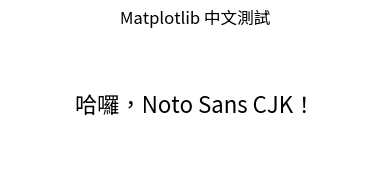

In [14]:
"""
跨平台載入 Noto Sans CJK 字型並驗證
在 VS Code + 本地 Python 環境執行
"""

import os
import sys
import platform
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---------- 1. 推斷各作業系統的預設字型路徑 ----------
def guess_noto_path() -> str | None:
    """回傳可能存在的 NotoSansCJK-Regular.ttc 路徑，找不到則回傳 None"""
    candidates = []

    match platform.system():
        case "Windows":
            candidates = [
                r"C:\Windows\Fonts\NotoSansCJK-Regular.ttc",
                r"C:\Windows\Fonts\NotoSansCJKtc-Regular.otf",
            ]
        case "Darwin":  # macOS
            candidates = [
                "/Library/Fonts/NotoSansCJK-Regular.ttc",
                "/System/Library/Fonts/NotoSansCJK.ttc",
            ]
        case "Linux":
            # 常見安裝位置；亦可加入 ~/.local/share/fonts
            candidates = [
                "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
                "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
                str(Path.home() / ".local/share/fonts/NotoSansCJK-Regular.ttc"),
            ]

    for p in candidates:
        if Path(p).is_file():
            return p
    return None


# ---------- 2. 取得字型路徑（可改為專案內相對路徑） ----------
# font_path = guess_noto_path()
font_path = 'NotoSansTC-Regular.ttf'  # 若已下載字型檔，請確認路徑正確

if font_path is None:
    # 若系統沒安裝，可改成專案相對路徑，例如 Path("fonts/NotoSansCJK-Regular.ttc")
    font_path = "fonts/NotoSansCJK-Regular.ttc"  # 請確認實際檔案位置
    if not Path(font_path).is_file():
        sys.exit(
            f"❌ 找不到 Noto Sans CJK 字型！\n"
            f"  請先安裝字型或把字型檔放到 {font_path}"
        )

# ---------- 3. 動態註冊並設定為預設中文字型 ----------
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()

# ---------- 4. 驗證 ----------
print("✅ 已載入字型：", plt.rcParams["font.family"])

# (可選) 畫個示範圖
plt.figure(figsize=(4, 2))
plt.title("Matplotlib 中文測試")
plt.text(0.5, 0.5, "哈囉，Noto Sans CJK！", ha="center", va="center", size=16)
plt.axis("off")
plt.tight_layout()
plt.show()


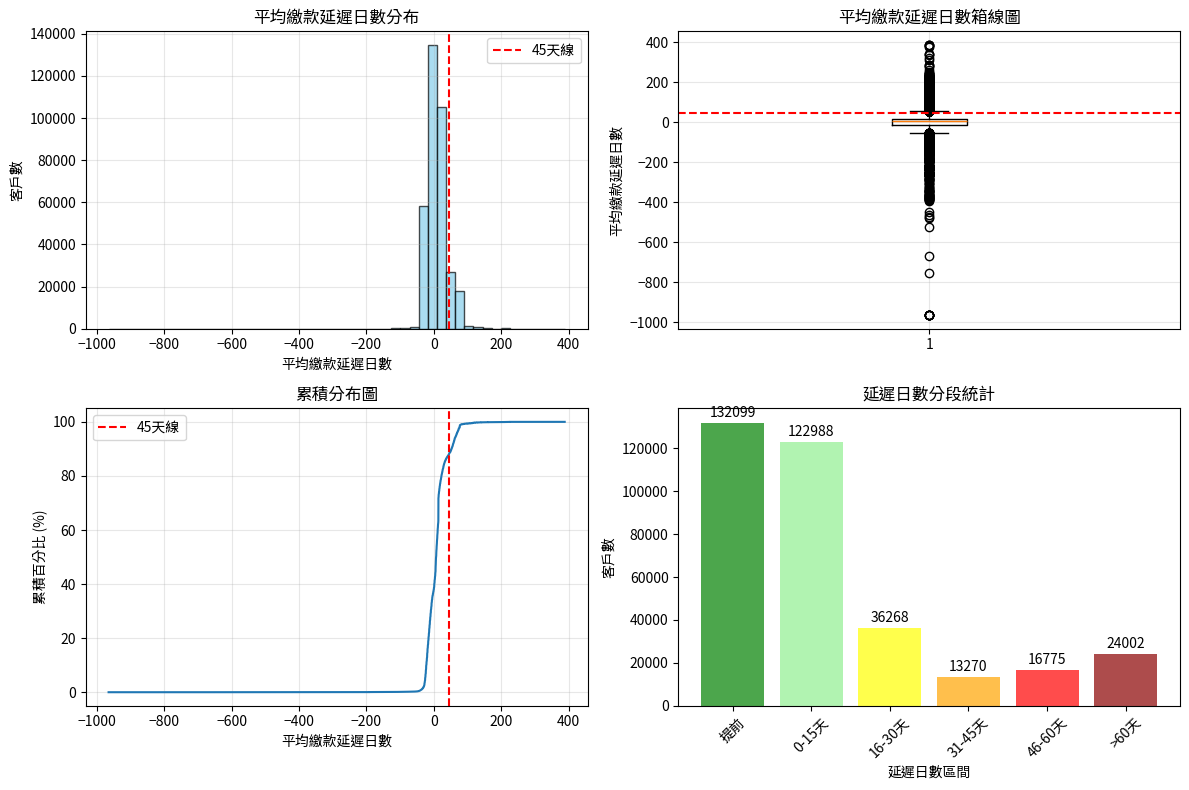


🎯 重點統計:
平均繳款延遲日數 < 45天的客戶: 305,669 筆
總客戶數: 347,223 筆
比例: 88.0%


In [15]:
# 視覺化平均繳款延遲日數分布
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if '平均繳款延遲日數' in ds_bill.columns:
    plt.figure(figsize=(12, 8))
    
    # 子圖1: 直方圖
    plt.subplot(2, 2, 1)
    plt.hist(ds_bill['平均繳款延遲日數'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(x=45, color='red', linestyle='--', label='45天線')
    plt.xlabel('平均繳款延遲日數')
    plt.ylabel('客戶數')
    plt.title('平均繳款延遲日數分布')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # 子圖2: 箱線圖
    plt.subplot(2, 2, 2)
    plt.boxplot(ds_bill['平均繳款延遲日數'].dropna())
    plt.axhline(y=45, color='red', linestyle='--', label='45天線')
    plt.ylabel('平均繳款延遲日數')
    plt.title('平均繳款延遲日數箱線圖')
    plt.grid(alpha=0.3)
    
    # 子圖3: 累積分布
    plt.subplot(2, 2, 3)
    delay_data = ds_bill['平均繳款延遲日數'].dropna().sort_values()
    cumulative_pct = np.arange(1, len(delay_data) + 1) / len(delay_data) * 100
    plt.plot(delay_data, cumulative_pct)
    plt.axvline(x=45, color='red', linestyle='--', label='45天線')
    plt.xlabel('平均繳款延遲日數')
    plt.ylabel('累積百分比 (%)')
    plt.title('累積分布圖')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # 子圖4: 分段統計條形圖
    plt.subplot(2, 2, 4)
    bins = [float('-inf'), 0, 15, 30, 45, 60, float('inf')]
    labels = ['提前', '0-15天', '16-30天', '31-45天', '46-60天', '>60天']
    counts = []
    
    for i in range(len(bins)-1):
        if bins[i] == float('-inf'):
            count = len(ds_bill[ds_bill['平均繳款延遲日數'] < bins[i+1]])
        elif bins[i+1] == float('inf'):
            count = len(ds_bill[ds_bill['平均繳款延遲日數'] > bins[i]])
        else:
            count = len(ds_bill[(ds_bill['平均繳款延遲日數'] > bins[i]) & 
                               (ds_bill['平均繳款延遲日數'] <= bins[i+1])])
        counts.append(count)
    
    colors = ['green', 'lightgreen', 'yellow', 'orange', 'red', 'darkred']
    bars = plt.bar(labels, counts, color=colors, alpha=0.7)
    plt.xlabel('延遲日數區間')
    plt.ylabel('客戶數')
    plt.title('延遲日數分段統計')
    plt.xticks(rotation=45)
    
    # 在條形圖上添加數值標籤
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                str(count), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # 特別標示45天以下的比例
    less_than_45_count = len(ds_bill[ds_bill['平均繳款延遲日數'] < 45])
    total_count = len(ds_bill)
    print(f"\n🎯 重點統計:")
    print(f"平均繳款延遲日數 < 45天的客戶: {less_than_45_count:,} 筆")
    print(f"總客戶數: {total_count:,} 筆")
    print(f"比例: {less_than_45_count/total_count*100:.1f}%")

In [16]:
# 刪除平均繳款延遲日數 < -60 的資料
print("=== 刪除平均繳款延遲日數 < -60 的資料 ===")

# 檢查ds_bill中是否有'平均繳款延遲日數'欄位
if '平均繳款延遲日數' in ds_bill.columns:
    # 檢查刪除前的資料狀況
    print(f"刪除前總客戶數: {len(ds_bill)}")
    
    # 找出平均繳款延遲日數 < -60 的資料
    extreme_early_payment = ds_bill[ds_bill['平均繳款延遲日數'] < -60]
    print(f"平均繳款延遲日數 < -60 的筆數: {len(extreme_early_payment)}")
    
    if len(extreme_early_payment) > 0:
        print(f"要刪除的資料佔比: {len(extreme_early_payment) / len(ds_bill) * 100:.2f}%")
        
        # 顯示要刪除的資料統計
        print(f"\n要刪除的資料統計:")
        print(extreme_early_payment['平均繳款延遲日數'].describe())
    
    # 執行刪除操作
    ds_bill_cleaned = ds_bill[ds_bill['平均繳款延遲日數'] >= -60].copy()
    
    print(f"\n刪除後總客戶數: {len(ds_bill_cleaned)}")
    print(f"實際刪除筆數: {len(ds_bill) - len(ds_bill_cleaned)}")
    
    # 更新ds_bill變數
    ds_bill = ds_bill_cleaned.copy()
    
    print(f"\n✅ 已成功刪除平均繳款延遲日數 < -60 的資料")
    
    # 顯示清理後的統計
    print(f"\n=== 清理後統計 ===")
    print(ds_bill['平均繳款延遲日數'].describe())
    
else:
    print("❌ 在ds_bill中找不到'平均繳款延遲日數'欄位")
    print(f"可用欄位: {list(ds_bill.columns)}")

=== 刪除平均繳款延遲日數 < -60 的資料 ===
刪除前總客戶數: 347223
平均繳款延遲日數 < -60 的筆數: 816
要刪除的資料佔比: 0.24%

要刪除的資料統計:
count    816.000000
mean    -144.601506
std      116.356139
min     -964.500000
25%     -190.500000
50%     -106.500000
75%      -79.000000
max      -60.250000
Name: 平均繳款延遲日數, dtype: float64

刪除後總客戶數: 346407
實際刪除筆數: 816

✅ 已成功刪除平均繳款延遲日數 < -60 的資料

=== 清理後統計 ===
count    346407.000000
mean          8.579014
std          28.043757
min         -60.000000
25%         -12.000000
50%           6.666667
75%          16.111111
max         388.000000
Name: 平均繳款延遲日數, dtype: float64


ds_bill 資料集中的 '最常見繳費方式' 欄位，保留內容為 CVS臨櫃代收(7-11)、 廠商代收、 簡訊帳單臨櫃代收(7-11)、 金融機構轉帳、 當月繳帳單、 信用卡扣款、 APP臨櫃代收(7-11) ，其餘內容改 '其他繳款方式'

In [17]:
#import pandas as pd

# Assuming ds_bill is already loaded
# ds_bill = pd.read_csv('/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/TrainData/ds_numService_with_billing.csv', sep=',')

# List of payment methods to keep
allowed_payment_methods = [
    "CVS臨櫃代收(7-11)",
    "廠商代收",
    "簡訊帳單臨櫃代收(7-11)",
    "金融機構轉帳",
    "當月繳帳單",
    "信用卡扣款",
    "APP臨櫃代收(7-11)"
]

# Replace other payment methods with '其他繳款方式'
ds_bill['最常見繳費方式'] = ds_bill['最常見繳費方式'].apply(lambda x: x if x in allowed_payment_methods else '其他繳款方式')

# Display the modified DataFrame (optional)
print(ds_bill.head())
print(ds_bill['最常見繳費方式'].value_counts())

         客編   平均繳款延遲日數         最常見繳費方式  繳別
10   895701 -46.700000          其他繳款方式  12
13  1129002  19.333333          其他繳款方式   1
14   223725  13.420000   CVS臨櫃代收(7-11)  12
30   533302 -43.285714  簡訊帳單臨櫃代收(7-11)   3
92  1026745 -34.800000  簡訊帳單臨櫃代收(7-11)  12
最常見繳費方式
CVS臨櫃代收(7-11)     127827
簡訊帳單臨櫃代收(7-11)     90401
其他繳款方式             51691
廠商代收               29196
當月繳帳單              28564
金融機構轉帳             15282
信用卡扣款               3262
APP臨櫃代收(7-11)        184
Name: count, dtype: int64


In [18]:
# ⬜ 1. 安裝／載入必要套件（Colab 已內建 pandas，通常不必另外安裝）
# import pandas as pd

# ⬜ 2. 讀取來源檔案
# ▸ 方式 A：直接從「檔案」側邊欄手動上傳 csv，再用下列路徑讀取
# file_path = "/content/ds_numService_with_billing.csv"   # ← 上傳後 Colab 的預設路徑

# ▸ 方式 B：若檔案在 Google Drive，先掛載 Drive
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = "/content/drive/MyDrive/your_folder/ds_numService_with_billing.csv"

# df = pd.read_csv(file_path)
df = ds_bill.copy()

print("原始資料筆數：", df.shape)

# ⬜ 3. 指定要做 one‑hot 的欄位
one_hot_cols = ["繳別", "最常見繳費方式"]

# 自訂各欄位的前綴（prefix）以便辨識
prefix_map = {
    "繳別": "paytype",
    "最常見繳費方式": "paymethod"
}

# ⬜ 4. 進行 one‑hot
df_encoded = pd.get_dummies(
    df,
    columns=one_hot_cols,
    prefix=[prefix_map[col] for col in one_hot_cols],
    dtype=int               # 產生 0/1 的 int 欄位
)

# ⬜ 5. 儲存處理後檔案
output_path = "ds_billing_onehot.csv"
df_encoded.to_csv(output_path, index=False, encoding="utf-8-sig")
print("完成 one‑hot 編碼，輸出檔案路徑:", output_path)

# ⬜ 6. 快速預覽前 5 列
df_encoded.head()


原始資料筆數： (346407, 4)
完成 one‑hot 編碼，輸出檔案路徑: ds_billing_onehot.csv


,客編,平均繳款延遲日數,paytype_1,paytype_3,paytype_6,paytype_12,paytype_15,paytype_99,paymethod_APP臨櫃代收(7-11),paymethod_CVS臨櫃代收(7-11),paymethod_信用卡扣款,paymethod_其他繳款方式,paymethod_廠商代收,paymethod_當月繳帳單,paymethod_簡訊帳單臨櫃代收(7-11),paymethod_金融機構轉帳
10,895701,-46.700000,0,0,0,1,0,0,0,0,0,1,0,0,0,0
13,1129002,19.333333,1,0,0,0,0,0,0,0,0,1,0,0,0,0
14,223725,13.420000,0,0,0,1,0,0,0,1,0,0,0,0,0,0
30,533302,-43.285714,0,1,0,0,0,0,0,0,0,0,0,0,1,0
92,1026745,-34.800000,0,0,0,1,0,0,0,0,0,0,0,0,1,0


In [19]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 346407 entries, 10 to 347218
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   客編                        346407 non-null  int64  
 1   平均繳款延遲日數                  346407 non-null  float64
 2   paytype_1                 346407 non-null  int64  
 3   paytype_3                 346407 non-null  int64  
 4   paytype_6                 346407 non-null  int64  
 5   paytype_12                346407 non-null  int64  
 6   paytype_15                346407 non-null  int64  
 7   paytype_99                346407 non-null  int64  
 8   paymethod_APP臨櫃代收(7-11)   346407 non-null  int64  
 9   paymethod_CVS臨櫃代收(7-11)   346407 non-null  int64  
 10  paymethod_信用卡扣款           346407 non-null  int64  
 11  paymethod_其他繳款方式          346407 non-null  int64  
 12  paymethod_廠商代收            346407 non-null  int64  
 13  paymethod_當月繳帳單           346407 non-null  int64

In [20]:
df_encoded.shape

(346407, 16)

In [ ]:
# ✅ 先安裝 imbalanced-learn（若在 Colab 尚未安裝）
# !pip install imbalanced-learn

# ✅ 匯入必要套件
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# ✅ 讀取資料（請將路徑換成自己的）
myDatasetPath='/content/ds_numService_with_billing_onehot.csv'
df = pd.read_csv(myDatasetPath)

# ✅ 資料清理與預處理
df = df.dropna().reset_index(drop=True)
y = df["使用狀態_數值"]

# 指定排除欄位
exclude_features = ['客編', '相關編號', '使用狀態_數值']

# 選擇 X 的特徵欄位 (排除指定欄位)
X = df.drop(columns=exclude_features)

# 數值標準化
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ✅ 使用 SMOTE 平衡樣本
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_scaled, y)

# ✅ 資料切分
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote)

# ✅ 對 SVM 使用 GridSearchCV 找最佳參數
'''
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}
# found Best SVM Params: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}

param_grid = {
    'C': [1, 10, 50, 100],
    'gamma': [0.1, 0.5, 1, 5],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}
# found Best SVM Params: {'C': 100, 'class_weight': 'balanced', 'gamma': 5, 'kernel': 'rbf'}
'''
'''
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [0.0001, 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf'],
}
# spent 21 hours more and not yet finish...
'''
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1],
    'kernel': ['rbf'],
}
# Best SVM Params: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
# cv=10, instead of 3
grid_search = GridSearchCV(SVC(), param_grid, cv=6, scoring='f1_macro', n_jobs=-1, verbose=30)  # 設定 verbose=3
grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_
print("Best SVM Params:", grid_search.best_params_)

# ✅ 定義模型字典
models = {
    "KNN (k=5, SMOTE)": KNeighborsClassifier(n_neighbors=5),
    "SVM (GridSearch, SMOTE)": best_svm,
    "Random Forest (SMOTE)": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

# ✅ 訓練與預測
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "confusion": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }

# ✅ 成果摘要表
summary = []
for name, result in results.items():
    report = result["report"]
    row = {
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision_0": report["0"]["precision"],
        "Recall_0": report["0"]["recall"],
        "F1_0": report["0"]["f1-score"],
        "Precision_1": report["1"]["precision"],
        "Recall_1": report["1"]["recall"],
        "F1_1": report["1"]["f1-score"]
    }
    summary.append(row)

df_summary = pd.DataFrame(summary)
print("\n📊 模型效能比較：")
print(df_summary)


Fitting 6 folds for each of 9 candidates, totalling 54 fits
Best SVM Params: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}

📊 模型效能比較：
                     Model  Accuracy  Precision_0  Recall_0      F1_0  \
0         KNN (k=5, SMOTE)  0.734131     0.741880  0.718114  0.729803   
1  SVM (GridSearch, SMOTE)  0.619864     0.605293  0.689056  0.644464   
2    Random Forest (SMOTE)  0.766166     0.755955  0.786114  0.770740   

   Precision_1  Recall_1      F1_1  
0     0.726864  0.750149  0.738323  
1     0.639115  0.550673  0.591607  
2     0.777226  0.746219  0.761407  


In [ ]:
import os
import joblib
import pickle
from datetime import datetime

# ✅ 動態前置路徑（可根據執行環境設定）
base_dir = "/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/TrainData/"
model_dir = os.path.join(base_dir, "saved_models")
os.makedirs(model_dir, exist_ok=True)

# 時間戳記版本號
version = datetime.now().strftime("v%Y%m%d_%H%M")

# 儲存為 .joblib
joblib.dump(models["KNN (k=5, SMOTE)"], os.path.join(model_dir, f"knn_model_{version}.joblib"))
joblib.dump(models["SVM (GridSearch, SMOTE)"], os.path.join(model_dir, f"svm_model_{version}.joblib"))
joblib.dump(models["Random Forest (SMOTE)"], os.path.join(model_dir, f"rf_model_{version}.joblib"))

# 儲存為 .pkl
with open(os.path.join(model_dir, f"knn_model_{version}.pkl"), "wb") as f:
    pickle.dump(models["KNN (k=5, SMOTE)"], f)
with open(os.path.join(model_dir, f"svm_model_{version}.pkl"), "wb") as f:
    pickle.dump(models["SVM (GridSearch, SMOTE)"], f)
with open(os.path.join(model_dir, f"rf_model_{version}.pkl"), "wb") as f:
    pickle.dump(models["Random Forest (SMOTE)"], f)

# 儲存轉換器
joblib.dump(scaler, os.path.join(model_dir, f"scaler_{version}.joblib"))
if "le" in locals():
    joblib.dump(le, os.path.join(model_dir, f"label_encoder_{version}.joblib"))

# 建立紀錄檔（log）
with open(os.path.join(model_dir, f"model_log_{version}.txt"), "w") as log:
    log.write("模型版本：" + version + "\n")
    log.write("儲存時間：" + datetime.now().strftime("%Y-%m-%d %H:%M:%S") + "\n")
    # log.write("特徵欄位：" + ", ".join(features) + "\n")
    log.write("模型摘要：\n")
    for row in df_summary.to_dict(orient="records"):
        for k, v in row.items():
            log.write(f"  {k}: {v}\n")
        log.write("\n")

print(f"✅ 模型與轉換器已成功儲存至：{model_dir}（版本：{version}）")


✅ 模型與轉換器已成功儲存至：/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/TrainData/saved_models（版本：v20250505_0612）


In [ ]:
# 匯入必要套件
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# 第一次使用需要下載 VADER 字典（如果已下載過，可以註解這行）
nltk.download('vader_lexicon')

# 讀取CSV（^ 分隔，Big5編碼）
file_path = '/content/csr-2025q1-100.csv'  # 改成你的檔案路徑
df = pd.read_csv(file_path, delimiter='^', encoding='big5')

# 確認欄位名稱是 ['CUST_NO', 'ED_SERVCLASSNAME', 'ED_SERVCLASS2NAME', 'CUST_RECORD_DATE', 'CUST_RECORD']

# 為一致性，重新命名欄位（只是內部用，不影響原檔）
df = df.rename(columns={
    'CUST_NO': 'cust_no',
    'ED_SERVCLASSNAME': 'main_category',
    'ED_SERVCLASS2NAME': 'sub_category',
    'CUST_RECORD_DATE': 'call_time',  # 雖然這次不會用到
    'CUST_RECORD': 'service_record'
})

# 初始化情緒分析器
sid = SentimentIntensityAnalyzer()

# 計算每筆紀錄的情緒分數（compound值）
df['sentiment_score'] = df['service_record'].fillna('').apply(lambda x: sid.polarity_scores(str(x))['compound'])

# 針對每個客戶進行彙總
def aggregate_customer(group):
    cust_no = group.name
    call_count = len(group)
    main_category = group['main_category'].mode().iloc[0] if not group['main_category'].mode().empty else None
    sub_category = group['sub_category'].mode().iloc[0] if not group['sub_category'].mode().empty else None
    sentiment_avg = group['sentiment_score'].mean()
    return pd.Series({
        'cust_no': cust_no,
        'call_count': call_count,
        'main_category': main_category,
        'sub_category': sub_category,
        'sentiment_avg': sentiment_avg
    })

# 套用分組匯總
result_df = df.groupby('cust_no').apply(aggregate_customer).reset_index(drop=True)

# 顯示前幾筆結果確認（必要時可取消註解）
print(result_df.head())

# （選擇性）儲存成新檔案
result_df.to_csv('訓練資料集.csv', index=False, encoding='utf-8-sig')


   cust_no  call_count main_category sub_category  sentiment_avg
0   159108           1        網路連線問題         無法上網            0.0
1   167802           1        網路連線問題         網路品質            0.0
2   190473           1          帳務相關         拆機挽回            0.0
3   325615           1          帳務相關         拆機挽回            0.0
4   335174           1        網路連線問題         無法上網            0.0


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
<ipython-input-2-097c4c722d14>:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result_df = df.groupby('cust_no').apply(aggregate_customer).reset_index(drop=True)


In [ ]:
result_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cust_no        97 non-null     int64  
 1   call_count     97 non-null     int64  
 2   main_category  97 non-null     object 
 3   sub_category   97 non-null     object 
 4   sentiment_avg  97 non-null     float64
dtypes: float64(1), int64(2), object(2)
memory usage: 3.9+ KB


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20296 (\N{CJK UNIFIED IDEOGRAPH-4F48}) missing from font(s) DejaVu Sans.
  fig.canvas

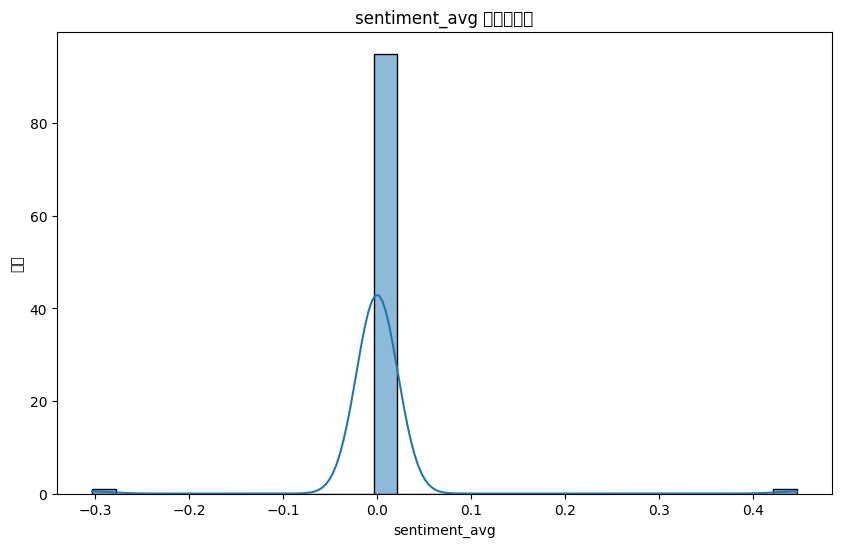

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))  # 調整圖表大小
sns.histplot(result_df['sentiment_avg'], bins=30, kde=True)  # bins 控制直方圖的區間數量，kde 顯示核密度估計
plt.title('sentiment_avg 的分佈情形')
plt.xlabel('sentiment_avg')
plt.ylabel('數量')
plt.show()